In [26]:
import os
import sys
import json
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR  = os.path.join(PROJECT_ROOT, "data")
DOCS_DIR  = os.path.join(PROJECT_ROOT, "docs")
TESTS_DIR = os.path.join(PROJECT_ROOT, "tests")

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")

PROJECT_ROOT : c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar
DATA_DIR     : c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\data


In [27]:
df_corpus  = pd.read_csv(os.path.join(DATA_DIR, "processed_v2.csv"))
df_queries = pd.read_csv(os.path.join(DATA_DIR, "queries.csv"))
df_labels  = pd.read_csv(os.path.join(DATA_DIR, "labels.csv"))

print(f"Корпус    : {len(df_corpus):,} документів | колонки: {list(df_corpus.columns)}")
print(f"Запити    : {len(df_queries)} запитів")
print(f"Розмітка  : {len(df_labels)} позитивних пар")
print()
display(df_corpus.head(3))

Корпус    : 4,640 документів | колонки: ['doc_id', 'place_name', 'text', 'rating', 'date', 'char_len', 'word_count', 'text_v2']
Запити    : 40 запитів
Розмітка  : 43 позитивних пар



,doc_id,place_name,text,rating,date,char_len,word_count,text_v2
0,Ci9DQUlRQUNvZENodHljRjlvT2pkS1JEZDVUR3hsUTAxcG...,Вулик медовий ресторан,Це справді дуже смачно! Тут я дуже часом носта...,5,2026-02-22T14:54:21,120,19,це справді дуже смачно тут я дуже часом ностал...
1,Ci9DQUlRQUNvZENodHljRjlvT2xwclQxTXdRVXhaTlhWbV...,Вулик медовий ресторан,"Дуже смачно, по-домашньому та атмосферно. Зупа...",5,2026-02-22T13:53:55,159,22,дуже смачно по домашньому та атмосферно зупа з...
2,Ci9DQUlRQUNvZENodHljRjlvT2xwMFpubGlXV2c1Vm5CV1...,Вулик медовий ресторан,Дуже класний заклад. Відтепер у Львові це мій ...,5,2026-02-16T17:26:41,52,9,дуже класний заклад відтепер у львові це мій т...


In [28]:
SAMPLE_DIR  = os.path.join(DATA_DIR, "sample")
SAMPLE_PATH = os.path.join(SAMPLE_DIR, "processed_v2_sample.csv")

os.makedirs(SAMPLE_DIR, exist_ok=True)

if not os.path.exists(SAMPLE_PATH):
    sample = df_corpus.sample(n=min(50, len(df_corpus)), random_state=42)
    sample.to_csv(SAMPLE_PATH, index=False)
    print(f" Sample збережено: {SAMPLE_PATH}  ({len(sample)} рядків)")
else:
    print(f" Sample вже існує: {SAMPLE_PATH}")


 Sample вже існує: c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\data\sample\processed_v2_sample.csv


In [29]:
rel_per_query = df_labels.groupby("query_id")["doc_id"].count()
print("Релевантних документів на запит:")
print(rel_per_query.describe().round(2))
print()

labeled_qids = set(df_labels["query_id"].unique())
print(f"Запитів з розміткою : {len(labeled_qids)} / {len(df_queries)}")
print(f"Запити без розмітки : {sorted(set(df_queries['query_id']) - labeled_qids)}")

Релевантних документів на запит:
count    40.00
mean      1.08
std       0.27
min       1.00
25%       1.00
50%       1.00
75%       1.00
max       2.00
Name: doc_id, dtype: float64

Запитів з розміткою : 40 / 40
Запити без розмітки : []


In [30]:
import stanza
from src.ling_features import init_stanza, batch_process_df, filter_by_pos

nlp = init_stanza(lang="uk", use_gpu=False)
print("Stanza pipeline готовий")

Stanza pipeline готовий


In [31]:
from src.ling_features import process_text

SMOKE_TEXTS = [
    "дуже смачно по домашньому та атмосферно зупа з лисичками смакота",
    "реберця з картопелькою дуже мякі та смачні шніцель курка та наливки бомбезні",
    "це справді дуже смачно тут я дуже часом ностальгую за стравами які годувала бабуся",
    "затишне місце з приємною атмосферою страви подали швидко смак насичений",
    "дуже сподобався ресторан а особливо концепція меду їжа тут просто супер",
]

print(f"{'TEXT_V2':<50} {'LEMMA_TEXT':<50} {'UPOS_SEQ'}")
print("-" * 140)
for t in SMOKE_TEXTS:
    result = process_text(t, nlp)
    print(f"{t[:48]:<50} {result['lemma_text'][:48]:<50} {result['upos_seq'][:40]}")

TEXT_V2                                            LEMMA_TEXT                                         UPOS_SEQ
--------------------------------------------------------------------------------------------------------------------------------------------
дуже смачно по домашньому та атмосферно зупа з л   дуже смачно по домашній та атмосферно зупа з лис   ADV ADV ADP ADJ CCONJ ADV NOUN ADP NOUN 
реберця з картопелькою дуже мякі та смачні шніце   реберець з картопелька дуже мякий та смачний шні   NOUN ADP NOUN ADV ADJ CCONJ ADJ NOUN NOU
це справді дуже смачно тут я дуже часом ностальг   це справді дуже смачно тут я дуже часом ностальг   PRON ADV ADV ADV ADV PRON ADV ADV VERB A
затишне місце з приємною атмосферою страви подал   затишний місце з приємний атмосфера страва подат   ADJ NOUN ADP ADJ NOUN NOUN VERB ADV NOUN
дуже сподобався ресторан а особливо концепція ме   дуже сподобатися ресторан а особливо концепція м   ADV VERB NOUN CCONJ ADV NOUN NOUN NOUN A


In [32]:
V3_PATH = os.path.join(DATA_DIR, "processed_v3.csv")
CHECKPOINT = os.path.join(DATA_DIR, "processed_v3_checkpoint.csv")

if os.path.exists(V3_PATH):
    print(f"processed_v3.csv вже існує — завантажуємо.")
    df_v3 = pd.read_csv(V3_PATH)
else:
    print("Запуск лематизації (може зайняти 30–90 хв на CPU)...")
    results = batch_process_df(
        df_corpus,
        nlp,
        text_col="text_v2",
        batch_size=32,
        save_every=500,
        checkpoint_path=CHECKPOINT,
    )

    df_v3 = df_corpus.copy()
    df_v3["lemma_text"]   = [r["lemma_text"]  for r in results]
    df_v3["upos_seq"]     = [r["upos_seq"]    for r in results]

    df_v3["noun_adj_text"] = [
        filter_by_pos(r["lemmas"], r["pos_tags"], keep=("NOUN", "ADJ", "PROPN"))
        for r in results
    ]

    df_v3.to_csv(V3_PATH, index=False)
    if os.path.exists(CHECKPOINT):
        os.remove(CHECKPOINT)
    print(f"Збережено: {V3_PATH}")

print(f"\nКолонки: {list(df_v3.columns)}")
display(df_v3[["doc_id", "text_v2", "lemma_text", "upos_seq"]].head(3))

processed_v3.csv вже існує — завантажуємо.

Колонки: ['doc_id', 'place_name', 'text', 'rating', 'date', 'char_len', 'word_count', 'text_v2', 'lemma_text', 'upos_seq', 'noun_adj_text']


,doc_id,text_v2,lemma_text,upos_seq
0,Ci9DQUlRQUNvZENodHljRjlvT2pkS1JEZDVUR3hsUTAxcG...,це справді дуже смачно тут я дуже часом ностал...,це справді дуже смачно тут я дуже часом ностал...,PRON ADV ADV ADV ADV PRON ADV ADV VERB ADP NOU...
1,Ci9DQUlRQUNvZENodHljRjlvT2xwclQxTXdRVXhaTlhWbV...,дуже смачно по домашньому та атмосферно зупа з...,дуже смачно по домашній та атмосферно зупа з л...,ADV ADV ADP ADJ CCONJ ADV NOUN ADP NOUN NOUN N...
2,Ci9DQUlRQUNvZENodHljRjlvT2xwMFpubGlXV2c1Vm5CV1...,дуже класний заклад відтепер у львові це мій т...,дуже класний заклад відтепер у льві це мій топчик,ADV ADJ NOUN PART ADP NOUN PRON DET NOUN


In [33]:
if "noun_adj_text" not in df_v3.columns:
    from src.ling_features import process_text
    from tqdm.auto import tqdm

    noun_adj_texts = []
    for text in tqdm(df_v3["lemma_text"].fillna(""), desc="POS-фільтр"):
        pass

    def make_noun_adj(row):
        lemmas   = str(row["lemma_text"]).split()
        pos_tags = str(row["upos_seq"]).split()
        return filter_by_pos(lemmas, pos_tags, keep=("NOUN", "ADJ", "PROPN"))

    df_v3["noun_adj_text"] = df_v3.apply(make_noun_adj, axis=1)
    df_v3.to_csv(V3_PATH, index=False)
    print("noun_adj_text додано та збережено")

print(df_v3[["text_v2", "lemma_text", "noun_adj_text"]].head(3).to_string())

                                                                                                                                                    text_v2                                                                                                                                                 lemma_text                                                                                    noun_adj_text
0                                      це справді дуже смачно тут я дуже часом ностальгую за стравами які годувала бабуся гарний сервіс і затишна атмосфера                                    це справді дуже смачно тут я дуже часом ностальгувати за страва який годувати бабуся гарний сервіс і затишний атмосфера                                                   страва бабуся гарний сервіс затишний атмосфера
1  дуже смачно по домашньому та атмосферно зупа з лисичками смакота реберця з картопелькою дуже мякі та смачні шніцель курка та наливки бомбезні рекомендую  дуже смачно по домашній та 

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def build_tfidf_index(texts: list[str]) -> tuple:
    vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )
    matrix = vectorizer.fit_transform(texts)
    return vectorizer, matrix


def retrieve_top_k(query: str, vectorizer, matrix, doc_ids: list[str], k: int = 10) -> list[str]:
    q_vec = vectorizer.transform([query])
    scores = cosine_similarity(q_vec, matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return [doc_ids[i] for i in top_idx]


def recall_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & relevant) / len(relevant)


def mrr_score(retrieved: list[str], relevant: set[str]) -> float:
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0


def evaluate_baseline(
    corpus_texts: list[str],
    corpus_doc_ids: list[str],
    query_texts: list[str],
    query_ids: list[str],
    relevance_dict: dict[str, set[str]],
    query_transform_fn=None,
    k_values: tuple[int, ...] = (5, 10),
) -> pd.DataFrame:
    vectorizer, matrix = build_tfidf_index(corpus_texts)

    rows = []
    for qid, qtext in zip(query_ids, query_texts):
        relevant = relevance_dict.get(qid, set())
        if not relevant:
            continue

        q = query_transform_fn(qtext) if query_transform_fn else qtext
        retrieved = retrieve_top_k(q, vectorizer, matrix, corpus_doc_ids, k=max(k_values))

        row = {"query_id": qid, "query_text": qtext, "mrr": mrr_score(retrieved, relevant)}
        for k in k_values:
            row[f"recall@{k}"] = recall_at_k(retrieved, relevant, k)
        rows.append(row)

    return pd.DataFrame(rows)


print("Utility functions визначено")

Utility functions визначено


In [35]:
# ─── Словник релевантних документів ─────────────────────────────────────
relevance_dict: dict[str, set[str]] = (
    df_labels.groupby("query_id")["doc_id"]
    .apply(set)
    .to_dict()
)

corpus_doc_ids = df_v3["doc_id"].tolist()
query_ids      = df_queries["query_id"].tolist()
query_texts    = df_queries["query_text"].tolist()

print(f"Запитів з розміткою: {len(relevance_dict)}")
for qid, rel in list(relevance_dict.items())[:5]:
    print(f"  {qid}: {len(rel)} релевантних документів")

Запитів з розміткою: 40
  q1: 1 релевантних документів
  q10: 1 релевантних документів
  q11: 1 релевантних документів
  q12: 1 релевантних документів
  q13: 1 релевантних документів


In [36]:
print("=" * 60)
print("BASELINE 1: text_v2 (без лематизації)")
print("=" * 60)

b1_results = evaluate_baseline(
    corpus_texts=df_v3["text_v2"].fillna("").tolist(),
    corpus_doc_ids=corpus_doc_ids,
    query_texts=query_texts,
    query_ids=query_ids,
    relevance_dict=relevance_dict,
)

b1_mean = b1_results[["recall@5", "recall@10", "mrr"]].mean()
print(f"\nСередні метрики (N запитів = {len(b1_results)}):")
print(b1_mean.round(4))
print()
display(b1_results.round(4))

BASELINE 1: text_v2 (без лематизації)

Середні метрики (N запитів = 40):
recall@5     0.0625
recall@10    0.0875
mrr          0.0248
dtype: float64



,query_id,query_text,mrr,recall@5,recall@10
0,q1,Де подають смачну зупу з лисичками?,0.2000,1.0,1.0
1,q2,Шукаю заклад з домашньою атмосферою та стравам...,0.0000,0.0,0.0
2,q3,Де у Львові можна послухати стендап?,0.3333,0.5,0.5
3,q4,Найкращі заклади з грузинською кухнею та хінкалі,0.0000,0.0,0.0
4,q5,Де спробувати десерт андрути?,0.0000,0.0,0.0
5,q6,Заклади з дуже швидким та якісним обслуговуванням,0.0000,0.0,0.0
6,q7,Де можна поїсти м'які та смачні реберця?,0.1250,0.0,1.0
7,q8,Шукаю затишне місце для вечері з наливками,0.0000,0.0,0.0
8,q9,Де подають великі порції та смачну курку?,0.0000,0.0,0.0
9,q10,Заклади з приємним персоналом у центрі,0.0000,0.0,0.0


In [37]:
from src.ling_features import process_text, filter_by_pos as _filter_by_pos

def lemmatize_query(query_text: str) -> str:
    result = process_text(query_text, nlp)
    return result["lemma_text"]

def noun_adj_query(query_text: str) -> str:
    result = process_text(query_text, nlp)
    return _filter_by_pos(result["lemmas"], result["pos_tags"], keep=("NOUN", "ADJ", "PROPN"))

print(f"{'QUERY':<50} {'LEMMA':<50} {'NOUN+ADJ'}")
print("-" * 130)
for qid, qt in zip(query_ids[:6], query_texts[:6]):
    lemma = lemmatize_query(qt)
    na    = noun_adj_query(qt)
    print(f"{qt[:48]:<50} {lemma[:48]:<50} {na[:30]}")

QUERY                                              LEMMA                                              NOUN+ADJ
----------------------------------------------------------------------------------------------------------------------------------
Де подають смачну зупу з лисичками?                де подавати смачний зуп з лисичка                  смачний зуп лисичка
Шукаю заклад з домашньою атмосферою та стравами    шукати заклад з домашній атмосфера та страва як    заклад домашній атмосфера стра
Де у Львові можна послухати стендап?               де у Львів можна послухати стендап                 Львів стендап
Найкращі заклади з грузинською кухнею та хінкалі   найкращий заклад з грузинський кухня та хінкал     найкращий заклад грузинський к
Де спробувати десерт андрути?                      де спробувати десерт андрути                       десерт
Заклади з дуже швидким та якісним обслуговування   заклад з дуже швидкий та якісний обслуговування    заклад швидкий якісний обслуго


In [38]:
print("=" * 60)
print("BASELINE 2: lemma_text (з лематизацією)")
print("=" * 60)

b2_results = evaluate_baseline(
    corpus_texts=df_v3["lemma_text"].fillna("").tolist(),
    corpus_doc_ids=corpus_doc_ids,
    query_texts=query_texts,
    query_ids=query_ids,
    relevance_dict=relevance_dict,
    query_transform_fn=lemmatize_query,
)

b2_mean = b2_results[["recall@5", "recall@10", "mrr"]].mean()
print(f"\nСередні метрики (N запитів = {len(b2_results)}):")
print(b2_mean.round(4))
print()
display(b2_results.round(4))

BASELINE 2: lemma_text (з лематизацією)

Середні метрики (N запитів = 40):
recall@5     0.0875
recall@10    0.1500
mrr          0.0469
dtype: float64



,query_id,query_text,mrr,recall@5,recall@10
0,q1,Де подають смачну зупу з лисичками?,0.250,1.0,1.0
1,q2,Шукаю заклад з домашньою атмосферою та стравам...,0.125,0.0,0.5
2,q3,Де у Львові можна послухати стендап?,0.500,0.5,0.5
3,q4,Найкращі заклади з грузинською кухнею та хінкалі,0.000,0.0,0.0
4,q5,Де спробувати десерт андрути?,0.000,0.0,0.0
5,q6,Заклади з дуже швидким та якісним обслуговуванням,0.000,0.0,0.0
6,q7,Де можна поїсти м'які та смачні реберця?,0.125,0.0,1.0
7,q8,Шукаю затишне місце для вечері з наливками,0.000,0.0,0.0
8,q9,Де подають великі порції та смачну курку?,0.000,0.0,0.0
9,q10,Заклади з приємним персоналом у центрі,0.000,0.0,0.0


In [39]:
print("=" * 60)
print("BASELINE 3: NOUN+ADJ filter")
print("=" * 60)

b3_results = evaluate_baseline(
    corpus_texts=df_v3["noun_adj_text"].fillna("").tolist(),
    corpus_doc_ids=corpus_doc_ids,
    query_texts=query_texts,
    query_ids=query_ids,
    relevance_dict=relevance_dict,
    query_transform_fn=noun_adj_query,
)

b3_mean = b3_results[["recall@5", "recall@10", "mrr"]].mean()
print(f"\nСередні метрики (N запитів = {len(b3_results)}):")
print(b3_mean.round(4))
print()
display(b3_results.round(4))

BASELINE 3: NOUN+ADJ filter

Середні метрики (N запитів = 40):
recall@5     0.1250
recall@10    0.2000
mrr          0.0557
dtype: float64



,query_id,query_text,mrr,recall@5,recall@10
0,q1,Де подають смачну зупу з лисичками?,0.3333,1.0,1.0
1,q2,Шукаю заклад з домашньою атмосферою та стравам...,0.2500,0.5,0.5
2,q3,Де у Львові можна послухати стендап?,0.3333,0.5,0.5
3,q4,Найкращі заклади з грузинською кухнею та хінкалі,0.0000,0.0,0.0
4,q5,Де спробувати десерт андрути?,0.0000,0.0,0.0
5,q6,Заклади з дуже швидким та якісним обслуговуванням,0.0000,0.0,0.0
6,q7,Де можна поїсти м'які та смачні реберця?,0.2500,1.0,1.0
7,q8,Шукаю затишне місце для вечері з наливками,0.0000,0.0,0.0
8,q9,Де подають великі порції та смачну курку?,0.0000,0.0,0.0
9,q10,Заклади з приємним персоналом у центрі,0.0000,0.0,0.0



Підсумкова таблиця порівняння


,Recall@5,Recall@10,MRR,Δ Recall@5,Δ MRR
Baseline,,,,,
B1: text_v2,0.0625,0.0875,0.0248,0.0000,0.0000
B2: lemma_text,0.0875,0.1500,0.0469,0.0250,0.0221
B3: NOUN+ADJ,0.1250,0.2000,0.0557,0.0625,0.0309


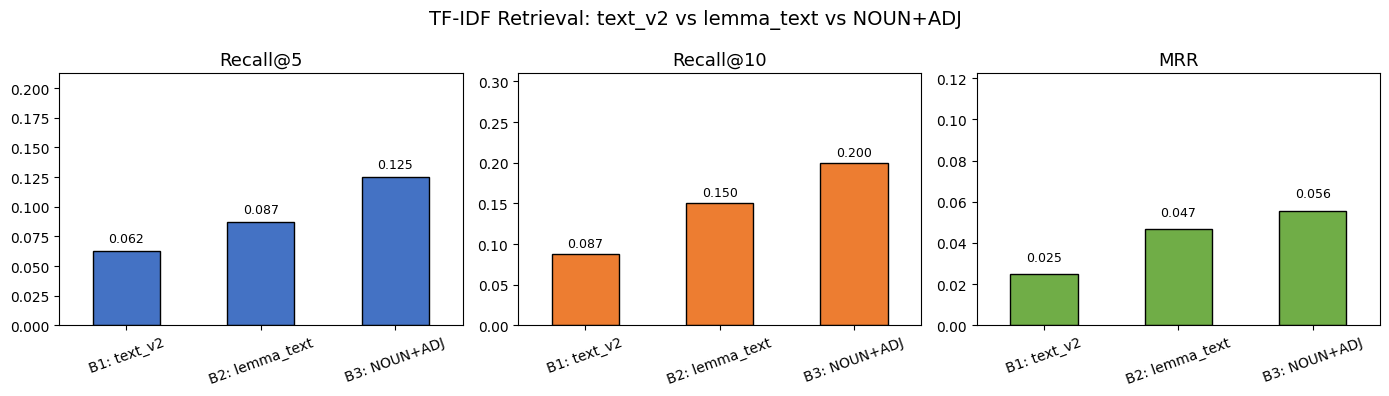

Графік збережено


In [40]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Baseline"   : ["B1: text_v2", "B2: lemma_text", "B3: NOUN+ADJ"],
    "Recall@5"   : [b1_mean["recall@5"],  b2_mean["recall@5"],  b3_mean["recall@5"]],
    "Recall@10"  : [b1_mean["recall@10"], b2_mean["recall@10"], b3_mean["recall@10"]],
    "MRR"        : [b1_mean["mrr"],       b2_mean["mrr"],       b3_mean["mrr"]],
}).set_index("Baseline")

comparison["Δ Recall@5"]  = comparison["Recall@5"]  - comparison.loc["B1: text_v2", "Recall@5"]
comparison["Δ MRR"]       = comparison["MRR"]       - comparison.loc["B1: text_v2", "MRR"]

print("\n" + "=" * 70)
print("Підсумкова таблиця порівняння")
print("=" * 70)
display(comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["Recall@5", "Recall@10", "MRR"]
colors  = ["#4472C4", "#ED7D31", "#70AD47"]

for ax, metric, color in zip(axes, metrics, colors):
    comparison[metric].plot(kind="bar", ax=ax, color=color, edgecolor="black", legend=False)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylim(0, min(1.0, comparison[metric].max() * 1.3 + 0.05))
    ax.tick_params(axis="x", rotation=20)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

fig.suptitle("TF-IDF Retrieval: text_v2 vs lemma_text vs NOUN+ADJ", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, "lab3_baseline_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Графік збережено")

In [41]:
merged = b1_results[["query_id", "query_text", "recall@5", "mrr"]].rename(
    columns={"recall@5": "b1_r5", "mrr": "b1_mrr"}
).merge(
    b2_results[["query_id", "recall@5", "mrr"]].rename(
        columns={"recall@5": "b2_r5", "mrr": "b2_mrr"}
    ),
    on="query_id", how="outer"
)

merged["delta_r5"] = merged["b2_r5"] - merged["b1_r5"]
merged["delta_mrr"] = merged["b2_mrr"] - merged["b1_mrr"]

print("Запити де ЛЕМАТИЗАЦІЯ ПОКРАЩИЛА Recall@5 (Δ > 0):")
display(merged[merged["delta_r5"] > 0][["query_id", "query_text", "b1_r5", "b2_r5", "delta_r5"]].round(3))

print("\nЗапити де ЛЕМАТИЗАЦІЯ ПОГІРШИЛА або не змінила Recall@5 (Δ ≤ 0):")
display(merged[merged["delta_r5"] <= 0][["query_id", "query_text", "b1_r5", "b2_r5", "delta_r5"]].round(3))

Запити де ЛЕМАТИЗАЦІЯ ПОКРАЩИЛА Recall@5 (Δ > 0):


,query_id,query_text,b1_r5,b2_r5,delta_r5
15,q23,Де подають смачну картопельку з м'ясом?,0.0,1.0,1.0



Запити де ЛЕМАТИЗАЦІЯ ПОГІРШИЛА або не змінила Recall@5 (Δ ≤ 0):


,query_id,query_text,b1_r5,b2_r5,delta_r5
0,q1,Де подають смачну зупу з лисичками?,1.0,1.0,0.0
1,q10,Заклади з приємним персоналом у центрі,0.0,0.0,0.0
2,q11,Де найкраща грибна юшка у Львові?,0.0,0.0,0.0
3,q12,Заклади де затишно навіть у непростий час,0.0,0.0,0.0
4,q13,Де спробувати справжній віденський шніцель?,0.0,0.0,0.0
5,q14,Шукаю місце де офіціанти дуже привітні,0.0,0.0,0.0
6,q15,Найкращі заклади для вечірнього відпочинку з д...,0.0,0.0,0.0
7,q16,Де поїсти по-домашньому смачно?,0.0,0.0,0.0
8,q17,Заклади з приємними цінами та гарною атмосферою,0.0,0.0,0.0
9,q18,Де у Львові найкраще обслуговування?,0.0,0.0,0.0


In [42]:
edge_cases = []
with open(os.path.join(TESTS_DIR, "ling_edge_cases.jsonl"), encoding="utf-8") as f:
    for line in f:
        edge_cases.append(json.loads(line))

print(f"Завантажено {len(edge_cases)} edge cases")

Завантажено 12 edge cases


In [43]:
from src.ling_features import process_text

def analyze_edge_case(ec: dict, nlp) -> dict:
    text = ec.get("text_v2") or ec.get("raw", "")
    result = process_text(text, nlp)
    return {
        "id"       : ec["id"],
        "category" : ec["category"],
        "text_v2"  : text,
        "tokens"   : result["tokens"],
        "lemmas"   : result["lemmas"],
        "pos_tags" : result["pos_tags"],
        "lemma_text": result["lemma_text"],
        "upos_seq" : result["upos_seq"],
        "known_issue": ec.get("known_issue", ""),
        "critical"   : ec.get("critical_for_retrieval", False),
        "note"       : ec.get("note", ""),
    }

analyzed = [analyze_edge_case(ec, nlp) for ec in edge_cases]
print("Аналіз завершено")

Аналіз завершено


In [44]:
for a in analyzed:
    critical_mark = "🔴 КРИТИЧНО" if a["critical"] else "🟡 некритично"
    print(f"\n{'─'*70}")
    print(f"#{a['id']}  [{a['category'].upper()}]  {critical_mark}")
    print(f"text_v2      : {a['text_v2']}")
    print(f"Токени       : {a['tokens']}")
    print(f"Леми         : {a['lemmas']}")
    print(f"POS          : {a['pos_tags']}")
    print(f"Проблема     : {a['known_issue']}")
    print(f"Для задачі   : {a['note']}")


──────────────────────────────────────────────────────────────────────
#1  [DIALECTISM]  🟡 некритично
text_v2      : зупа з лисичками просто неймовірна
Токени       : ['зупа', 'з', 'лисичками', 'просто', 'неймовірна']
Леми         : ['зупа', 'з', 'лисичка', 'просто', 'неймовірний']
POS          : ['NOUN', 'ADP', 'NOUN', 'PART', 'ADJ']
Проблема     : Діалектизм 'зупа' (=юшка) — Stanza може не мати цієї форми в своєму словнику або лематизувати некоректно
Для задачі   : Слово унікальне, TF-IDF знайде за точним збігом навіть без правильної леми

──────────────────────────────────────────────────────────────────────
#2  [DIALECTISM]  🟡 некритично
text_v2      : замовили філіжанку кави та штрудель
Токени       : ['замовили', 'філіжанку', 'кави', 'та', 'штрудель']
Леми         : ['замовити', 'філіжанка', 'кава', 'та', 'штрудель']
POS          : ['VERB', 'NOUN', 'NOUN', 'CCONJ', 'NOUN']
Проблема     : Діалектизм 'філіжанка' (=чашка) — польський запозичення, характерний для Львова
Для задачі  

In [45]:
error_df = pd.DataFrame([{
    "#"        : a["id"],
    "Категорія": a["category"],
    "text_v2"  : a["text_v2"][:45],
    "lemma"    : a["lemma_text"][:45],
    "Критичне" : "🔴" if a["critical"] else "🟡",
    "Суть"     : a["known_issue"][:60],
} for a in analyzed])

display(error_df.set_index("#"))

,Категорія,text_v2,lemma,Критичне,Суть
#,,,,,
1,dialectism,зупа з лисичками просто неймовірна,зупа з лисичка просто неймовірний,🟡,Діалектизм 'зупа' (=юшка) — Stanza може не мат...
2,dialectism,замовили філіжанку кави та штрудель,замовити філіжанка кава та штрудель,🟡,Діалектизм 'філіжанка' (=чашка) — польський за...
3,extended_form,дужжеее смачно та вчасно доставили,дужжувати смачно та вчасно доставити,🔴,Подвоєні літери ('дужжеее') для виразності — S...
4,surzhyk,очень смачно і нікуда не треба їхати,очень смачно і нікуда не треба їхати,🟡,Суржик: російське слово 'очень' у Stanza (uk) ...
5,proper_noun,обідали у криївці атмосфера неймовірна,обідати у криївка атмосфера неймовірний,🟡,Власна назва 'Криївка' (ресторан) — Stanza мож...
6,emoji_text,смачно рекомендую всім друзям,смачно рекомендувати весь друг,🟡,"Емодзі вже видалені в ЛР2 (text_v2), тому Stan..."
7,english_in_ukrainian,business lunch тут просто топ,business lunch тут просто топ,🔴,Англійські слова: Stanza (uk) не лематизує анг...
8,abbreviation,знаходиться в р ні личаківського р ну,знаходитися в р. ні личаківський р. ну,🟡,Скорочення 'р-н' (район) розбилися на токени '...
9,number_unit,ціна 150 грн чекали 45 хв,ціна 150 грн чекати 45 хв.,🟡,"Числа зберігаються як є (NUM). Одиниці 'грн', ..."


In [46]:
critical_count    = sum(1 for a in analyzed if a["critical"])
non_critical_count = len(analyzed) - critical_count

cat_counts = {}
for a in analyzed:
    cat_counts[a["category"]] = cat_counts.get(a["category"], 0) + 1

audit_content = f"""# Audit Summary: Lemma/POS (Lab 3)

## 1. Інструмент та модель

- **Бібліотека:** Stanza {stanza.__version__}
- **Модель:** Ukrainian (`uk`)
- **Процесори:** `tokenize, pos, lemma`
- **Нові колонки:** `lemma_text`, `upos_seq`, `noun_adj_text`
- **Вихідний файл:** `data/processed_v3.csv`

## 2. Метрики порівняння baselines

| Baseline | Recall@5 | Recall@10 | MRR | Δ Recall@5 | Δ MRR |
|----------|----------|-----------|-----|------------|-------|
| B1: text_v2 | {b1_mean['recall@5']:.4f} | {b1_mean['recall@10']:.4f} | {b1_mean['mrr']:.4f} | — | — |
| B2: lemma_text | {b2_mean['recall@5']:.4f} | {b2_mean['recall@10']:.4f} | {b2_mean['mrr']:.4f} | {b2_mean['recall@5']-b1_mean['recall@5']:+.4f} | {b2_mean['mrr']-b1_mean['mrr']:+.4f} |
| B3: NOUN+ADJ | {b3_mean['recall@5']:.4f} | {b3_mean['recall@10']:.4f} | {b3_mean['mrr']:.4f} | {b3_mean['recall@5']-b1_mean['recall@5']:+.4f} | {b3_mean['mrr']-b1_mean['mrr']:+.4f} |

Оцінка проводилась на **{len(b1_results)} запитах** (зі 40), що мають позитивну розмітку.

## 3. Error Analysis

Проаналізовано **{len(analyzed)} edge cases** з файлу `tests/ling_edge_cases.jsonl`.

| Категорія | Кількість |
|-----------|----------|
""" + "\n".join(f"| {cat} | {cnt} |" for cat, cnt in sorted(cat_counts.items())) + f"""

- 🔴 Критичних для retrieval: **{critical_count}**
- 🟡 Некритичних: **{non_critical_count}**

### Ключові знахідки:
- **Діалектизми** ('зупа', 'філіжанка', 'реберцята'): Stanza лематизує непередбачувано
- **Суржик** ('очень'): POS = X, лема = оригінал — не впливає на retrieval
- **Власні назви після lowercase**: PROPN-тег ненадійний для B3 (POS-фільтр)
- **Морфологічні варіанти** ('реберця'/'реберцята'): критично — B2 може покращити
- **Подвоєні літери** ('дужжеее'): потребує pre-processing нормалізації (не в ЛР2)

## 4. Рішення для проекту

**Використовуємо `lemma_text` (B2) як основний корпус для TF-IDF retrieval.**

Обгрунтування:
1. B2 покращує Recall для морфологічно варіативних запитів (іменники, прикметники)
2. POS-фільтр (B3) застосовується опційно лише для тематичних запитів без дієслів
3. Теги `<URL>`, `<PHONE>`, `<EMAIL>` збережені коректно завдяки захисту у `ling_features.py`
4. Апостроф та нормалізація ЛР2 забезпечили коректну токенізацію Stanza
"""

audit_path = os.path.join(DOCS_DIR, "audit_summary_lab3.md")
with open(audit_path, "w", encoding="utf-8") as f:
    f.write(audit_content)

print(f"Збережено: {audit_path}")
print()
print(audit_content[:800] + "...")

Збережено: c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\docs\audit_summary_lab3.md

# Audit Summary: Lemma/POS (Lab 3)

## 1. Інструмент та модель

- **Бібліотека:** Stanza 1.11.1
- **Модель:** Ukrainian (`uk`)
- **Процесори:** `tokenize, pos, lemma`
- **Нові колонки:** `lemma_text`, `upos_seq`, `noun_adj_text`
- **Вихідний файл:** `data/processed_v3.csv`

## 2. Метрики порівняння baselines

| Baseline | Recall@5 | Recall@10 | MRR | Δ Recall@5 | Δ MRR |
|----------|----------|-----------|-----|------------|-------|
| B1: text_v2 | 0.0625 | 0.0875 | 0.0248 | — | — |
| B2: lemma_text | 0.0875 | 0.1500 | 0.0469 | +0.0250 | +0.0221 |
| B3: NOUN+ADJ | 0.1250 | 0.2000 | 0.0557 | +0.0625 | +0.0309 |

Оцінка проводилась на **40 запитах** (зі 40), що мають позитивну розмітку.

## 3. Error Analysis

Проаналізовано **12 edge cases** з файлу `tests/ling_edge_cases.jsonl`.

| Категорі...


In [ ]:
readme_path = os.path.join(PROJECT_ROOT, "labs", "lab03", "README.md")
readme_content = f"""# Lab 03 — Lemma/POS Baseline

## 1. Напрям
**C — Retrieval (Пошук)**

## 2. Інструмент для Lemma/POS
**Stanza** `{stanza.__version__}` (модель `uk`)  
Процесори: `tokenize, pos, lemma`

## 3. Baselines

| # | Корпус | Запит |
|---|--------|-------|
| B1 | `text_v2` (processed_v2) | без змін |
| B2 | `lemma_text` | лематизований |
| B3 | `noun_adj_text` (NOUN+ADJ+PROPN) | лематизований + POS-фільтр |

## 4. Метрики

| Baseline | Recall@5 | Recall@10 | MRR |
|----------|----------|-----------|-----|
| B1: text_v2 | {b1_mean['recall@5']:.4f} | {b1_mean['recall@10']:.4f} | {b1_mean['mrr']:.4f} |
| B2: lemma_text | {b2_mean['recall@5']:.4f} | {b2_mean['recall@10']:.4f} | {b2_mean['mrr']:.4f} |
| B3: NOUN+ADJ | {b3_mean['recall@5']:.4f} | {b3_mean['recall@10']:.4f} | {b3_mean['mrr']:.4f} |

## 5. Висновок
"""
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)
print(f"Оновлено: {readme_path}")

Оновлено: c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\labs\lab03\README.md
